In [ ]:
# Install deps
!pip install -q pandas scikit-learn matplotlib seaborn numpy

import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report

os.chdir('/content')
!rm -rf NLP_Course
REPO_URL = "https://github.com/dmytroslav/NLP_Course.git"
!git clone $REPO_URL
sys.path.append('/content/NLP_Course/src')

from svm_experiments import run_linear_svc
from threshold_eval import evaluate_thresholds

Cloning into 'NLP_Course'...
remote: Enumerating objects: 147, done.
remote: Counting objects: 100% (147/147), done.
remote: Compressing objects: 100% (104/104), done.
remote: Total 147 (delta 56), reused 119 (delta 31), pack-reused 0 (from 0)
Receiving objects: 100% (147/147), 1.97 MiB | 21.50 MiB/s, done.
Resolving deltas: 100% (56/56), done.


In [ ]:
# Section 2 & 3: Data access & Load split
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

data_path = '/content/NLP_Course/data/processed_v2.csv'
train_idx_path = '/content/NLP_Course/data/sample/splits_train_ids.txt'
val_idx_path = '/content/NLP_Course/data/sample/splits_val_ids.txt'
test_idx_path = '/content/NLP_Course/data/sample/splits_test_ids.txt'

try:
    df = pd.read_csv(data_path)

    df['text'] = df['text'].fillna('')

    train_idx = pd.read_csv(train_idx_path, header=None)[0].values
    val_idx = pd.read_csv(val_idx_path, header=None)[0].values
    test_idx = pd.read_csv(test_idx_path, header=None)[0].values

    # Створюємо спліти за допомогою .iloc (вибір за номером рядка)
    X_train = df.iloc[train_idx]['text']
    y_train = df.iloc[train_idx]['label']

    X_val = df.iloc[val_idx]['text']
    y_val = df.iloc[val_idx]['label']

    X_test = df.iloc[test_idx]['text']
    y_test = df.iloc[test_idx]['label']

    print(f"Train size: {len(X_train)}, Val size: {len(X_val)}, Test size: {len(X_test)}")

except FileNotFoundError as e:
    print(f"Помилка: {e}. Перевір шляхи до файлів!")
except Exception as e:
    print(f"Виникла помилка: {e}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train size: 8587, Val size: 1074, Test size: 1074


In [ ]:
# Section 4: Reproduce Lab6 baseline (TF-IDF word(1,2) + LogReg balanced)
print("=== Варіант 1: Baseline з ЛР6 (LogReg) ===")
pipeline_logreg = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1, 2))),
    ('clf', LogisticRegression(class_weight='balanced', random_state=42))
])

pipeline_logreg.fit(X_train, y_train)
y_pred_logreg = pipeline_logreg.predict(X_test)

acc_logreg = accuracy_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg, average='macro')

print(f"Accuracy: {acc_logreg:.4f}")
print(f"Macro-F1: {f1_logreg:.4f}")

=== Варіант 1: Baseline з ЛР6 (LogReg) ===
Accuracy: 0.8939
Macro-F1: 0.8510


In [ ]:
# Section 5 & 6: Linear SVM baselines

# Варіант 2: SVM word baseline
print("\n=== Варіант 2: LinearSVC (word(1,2)) ===")
pipeline_svc_word = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='word', ngram_range=(1, 2), sublinear_tf=True)),
    ('clf', LinearSVC(C=1.0, class_weight='balanced', random_state=42, dual=False))
])
pipeline_svc_word.fit(X_train, y_train)
y_pred_svc_word = pipeline_svc_word.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_svc_word):.4f}")
print(f"Macro-F1: {f1_score(y_test, y_pred_svc_word, average='macro'):.4f}")

# Варіант 3: SVM char-ngrams baseline (char_wb 3-5)
print("\n=== Варіант 3: LinearSVC (char_wb(3,5)) ===")
pipeline_svc_char = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 5), sublinear_tf=True)),
    ('clf', LinearSVC(C=1.0, class_weight='balanced', random_state=42, dual=False))
])
pipeline_svc_char.fit(X_train, y_train)
y_pred_svc_char = pipeline_svc_char.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred_svc_char):.4f}")
print(f"Macro-F1: {f1_score(y_test, y_pred_svc_char, average='macro'):.4f}")


=== Варіант 2: LinearSVC (word(1,2)) ===
Accuracy: 0.9125
Macro-F1: 0.8750

=== Варіант 3: LinearSVC (char_wb(3,5)) ===
Accuracy: 0.9236
Macro-F1: 0.8903


=== Оцінка порогів на Validation Set ===
Класи моделі: [False  True] (негативні scores -> False, позитивні -> True)


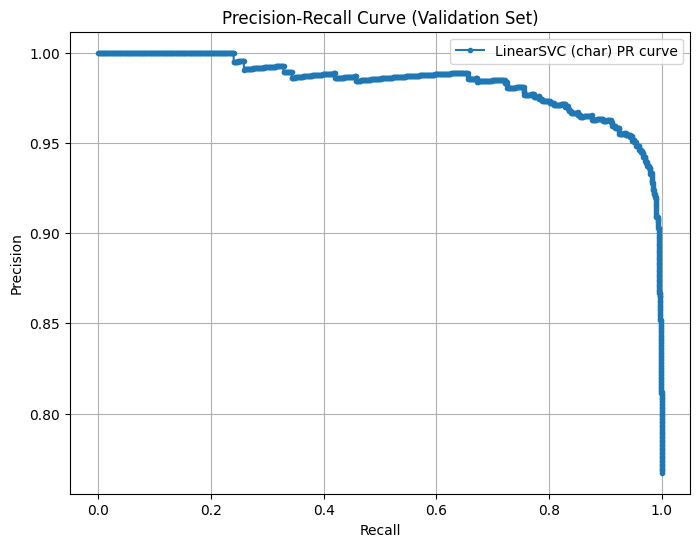


--- Вплив порогу на міноритарний клас (False - Фейки) ---
Threshold: -0.5 | Precision: 0.9755 | Recall: 0.6360 | F1-Score: 0.7700
Threshold: -0.2 | Precision: 0.9307 | Recall: 0.7520 | F1-Score: 0.8319
Threshold:  0.0 | Precision: 0.8821 | Recall: 0.8080 | F1-Score: 0.8434
Threshold:  0.2 | Precision: 0.7839 | Recall: 0.8560 | F1-Score: 0.8184
Threshold:  0.5 | Precision: 0.5928 | Recall: 0.9200 | F1-Score: 0.7210


In [ ]:
# Section 8: PR-curve / threshold section
print("=== Оцінка порогів на Validation Set ===")

y_scores_val = pipeline_svc_char.decision_function(X_val)

classes = pipeline_svc_char.classes_
print(f"Класи моделі: {classes} (негативні scores -> {classes[0]}, позитивні -> {classes[1]})")

from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

y_val_bool = (y_val == classes[1])

# PR-кривa
precision, recall, thresholds = precision_recall_curve(y_val_bool, y_scores_val)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, marker='.', label='LinearSVC (char) PR curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Validation Set)')
plt.legend()
plt.grid()
plt.show()

thresholds_to_test = [-0.5, -0.2, 0.0, 0.2, 0.5]

print("\n--- Вплив порогу на міноритарний клас (False - Фейки) ---")
for thresh in thresholds_to_test:
    # Якщо score > thresh, прогнозуємо True, інакше False
    y_pred_custom = (y_scores_val >= thresh)

    # Оцінюємо саме для класу False (pos_label=False)
    p = precision_score(y_val_bool, y_pred_custom, pos_label=False)
    r = recall_score(y_val_bool, y_pred_custom, pos_label=False)
    f1 = f1_score(y_val_bool, y_pred_custom, pos_label=False)

    print(f"Threshold: {thresh:>4} | Precision: {p:.4f} | Recall: {r:.4f} | F1-Score: {f1:.4f}")

=== Фінальна оцінка LinearSVC (char_wb) на TEST SET (Threshold = 0.0) ===
Test Accuracy: 0.9236
Test Macro-F1: 0.8903


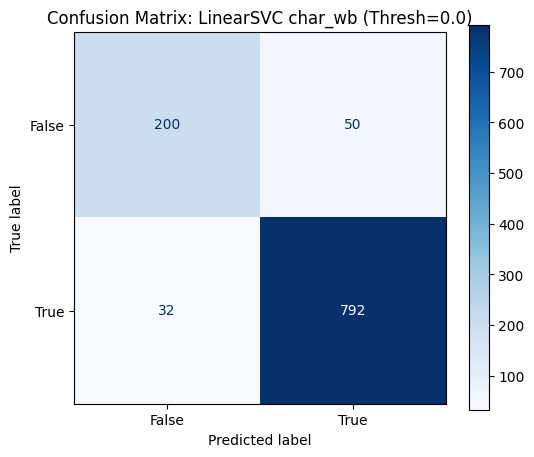

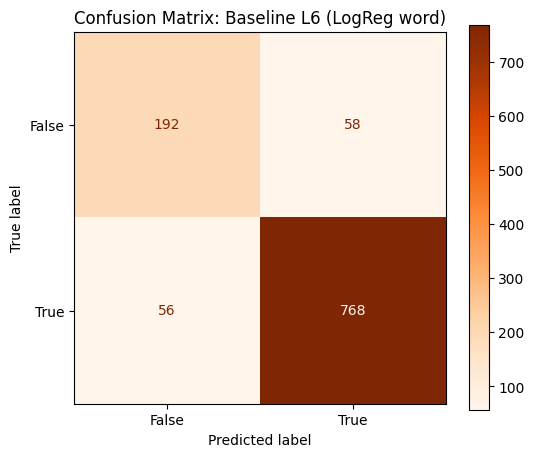

In [ ]:
# Section 9: Confusion matrix comparison & Final Test Eval
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

CHOSEN_THRESHOLD = 0.0

print(f"=== Фінальна оцінка LinearSVC (char_wb) на TEST SET (Threshold = {CHOSEN_THRESHOLD}) ===")

y_scores_test = pipeline_svc_char.decision_function(X_test)
y_pred_test_custom = (y_scores_test >= CHOSEN_THRESHOLD)
y_test_bool = (y_test == pipeline_svc_char.classes_[1])

acc_test = accuracy_score(y_test_bool, y_pred_test_custom)
f1_test = f1_score(y_test_bool, y_pred_test_custom, average='macro')

print(f"Test Accuracy: {acc_test:.4f}")
print(f"Test Macro-F1: {f1_test:.4f}")

cm_svm = confusion_matrix(y_test_bool, y_pred_test_custom)
disp_svm = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=['False', 'True'])

fig, ax = plt.subplots(figsize=(6, 5))
disp_svm.plot(ax=ax, cmap='Blues')
plt.title(f'Confusion Matrix: LinearSVC char_wb (Thresh={CHOSEN_THRESHOLD})')
plt.show()

y_pred_logreg_bool = (y_pred_logreg == pipeline_svc_char.classes_[1])
cm_logreg = confusion_matrix(y_test_bool, y_pred_logreg_bool)
disp_logreg = ConfusionMatrixDisplay(confusion_matrix=cm_logreg, display_labels=['False', 'True'])

fig, ax = plt.subplots(figsize=(6, 5))
disp_logreg.plot(ax=ax, cmap='Oranges')
plt.title('Confusion Matrix: Baseline L6 (LogReg word)')
plt.show()

In [ ]:
# Section 10: Error analysis
import numpy as np

print("=== Розбір 10 помилок (LinearSVC char_wb) ===")
errors_idx = np.where(y_test_bool != y_pred_test_custom)[0]

for i, idx in enumerate(errors_idx[:10]):
    text_id = X_test.index[idx]
    text = X_test.iloc[idx]
    gold = "True" if y_test_bool.iloc[idx] else "False"
    pred = "True" if y_pred_test_custom[idx] else "False"

    print(f"\n[Помилка #{i+1}] text_id: {text_id}")
    print(f"Text: {text[:250]}...")
    print(f"Gold Label: {gold} | Predicted Label: {pred}")
    print("-" * 60)

=== Розбір 10 помилок (LinearSVC char_wb) ===

[Помилка #1] text_id: 9332
Text: Росія стягує до кордонів України застарілу техніку Українські ЗМІ посилаються на заяву спікера міжнародної розвідувальної спільноти InformNapalm Михайла Макарука....
Gold Label: False | Predicted Label: True
------------------------------------------------------------

[Помилка #2] text_id: 2849
Text: Шахіст Сергій Карякін нагороджений медаллю ордена "За заслуги перед Батьківщиною" II ступеня Раніше він підтримав військову операцію Росії в Україні....
Gold Label: True | Predicted Label: False
------------------------------------------------------------

[Помилка #3] text_id: 4501
Text: Українська розвідка отримала внутрішні документи армії Росії, які свідчать, що російські військові не отримують обіцяних їм грошових виплат...
Gold Label: True | Predicted Label: False
------------------------------------------------------------

[Помилка #4] text_id: 10546
Text: На Кримському мості горить усі полотно автомоб